In [1]:
import pandas as pd

data = pd.read_csv("../data_raw/Loan_default.csv")
data.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [2]:
    data = data.drop(columns=["LoanID"])
X = data.drop(columns=["Default"])
y = data["Default"]
X = pd.get_dummies(X, drop_first=True)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


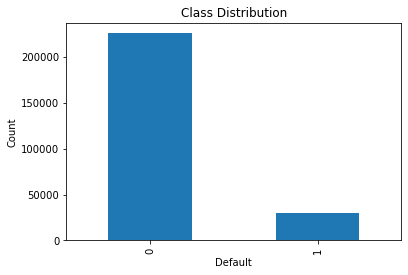

In [5]:

import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()


In [7]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print(classification_report(y_test, gb_pred))


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.65      0.05      0.09      5900

    accuracy                           0.89     51070
   macro avg       0.77      0.52      0.52     51070
weighted avg       0.86      0.89      0.84     51070

